**Tarea 2**

Estudiantes: Sofía Fariña y Martina Retamales.

In [1]:
#A.0.1 Load the ENO dataset
import pandas as pd
eno_cols = ["ENO", "anho_notificacion", "region", "codigo_comuna_residencia",
"nacionalidad", "sexo", "grupo_edad", "nombre_instruccion",
"cie_10_diagnostico", "diagnostico", "pais_contagio"]
eno = pd.read_csv("/content/20241218_base_eno_final.csv",sep=";", encoding="utf-8-sig", usecols=eno_cols)
eno.shape
eno.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    333300 non-null  object
 1   nacionalidad              333300 non-null  object
 2   cie_10_diagnostico        333300 non-null  object
 3   diagnostico               333300 non-null  object
 4   anho_notificacion         333300 non-null  int64 
 5   ENO                       333300 non-null  object
 6   nombre_instruccion        333300 non-null  object
 7   pais_contagio             333300 non-null  object
 8   sexo                      333300 non-null  object
 9   grupo_edad                333300 non-null  object
 10  codigo_comuna_residencia  333300 non-null  object
dtypes: int64(1), object(10)
memory usage: 28.0+ MB


In [2]:
#A.0.2 Filter to your comunas
MY_COMUNAS = [13122, 13605] #Penañolen y Peñaflor
my_comunas_str = [str(c) for c in MY_COMUNAS]
eno_com = eno[eno["codigo_comuna_residencia"].isin(my_comunas_str)] #df con los datos de las comunas
print(f"Rows in my comunas: {len(eno_com):,}")
# Total de filas
total_rows = len(eno)
# Filas con comuna anonimizada
anon_rows = (eno["codigo_comuna_residencia"] == "*****").sum()
# Porcentaje
anon_pct = anon_rows / total_rows * 100
print(f"Filas anonimizada (*****): {anon_rows:,}")
print(f"Porcentaje: {anon_pct:.2f}%")
eno["codigo_comuna_residencia"].value_counts().head()

Rows in my comunas: 1,928
Filas anonimizada (*****): 148,217
Porcentaje: 44.47%


,count
codigo_comuna_residencia,
*****,148217
13101,12186
02101,5130
05109,4767
05101,4397


Aproximadamente el 44.47% de los registros del dataset ENO tienen la comuna de residencia anonimizada ("*****"), lo que corresponde a 148,217 filas.

Esto implica una limitación importante del análisis, ya que estos casos no pueden ser asignados a una comuna específica.

In [3]:
# A.0.3 Limpieza de nacionalidad

# Distribución de nacionalidad en mis comunas (Peñalolen y Peñaflor)
nat_counts = eno_com["nacionalidad"].value_counts(dropna=False)
nat_pct = eno_com["nacionalidad"].value_counts(normalize=True, dropna=False) * 100
nat_dist = pd.DataFrame({"count": nat_counts, "pct": nat_pct.round(2)})
print("Distribución de nacionalidad en mis comunas:")
display(nat_dist)

# Filas con nacionalidad desconocida
n_desconocido = (eno_com["nacionalidad"] == "Desconocido").sum()
pct_desconocido = n_desconocido / len(eno_com) * 100
print(f"Filas con nacionalidad 'Desconocido': {n_desconocido:,}")
print(f"Porcentaje sobre mis comunas: {pct_desconocido:.2f}%")

# Base para análisis por nacionalidad: excluir Desconocido
eno_com_nat = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()
print(f"Filas después de excluir 'Desconocido': {len(eno_com_nat):,}")
print(f"Filas eliminadas: {n_desconocido:,}")

Distribución de nacionalidad en mis comunas:


,count,pct
nacionalidad,,
Chile,952,49.38
Desconocido,820,42.53
Extranjero,156,8.09


Filas con nacionalidad 'Desconocido': 820
Porcentaje sobre mis comunas: 42.53%
Filas después de excluir 'Desconocido': 1,108
Filas eliminadas: 820


In [4]:
# A.0.4 Report the time span

# Año mínimo y máximo
min_year = eno_com["anho_notificacion"].min()
max_year = eno_com["anho_notificacion"].max()
print(f"Rango de años filtrados son desde: {min_year} - {max_year}")

# Notificaciones por año: cuetno por año y genero la tabla
year_counts = eno_com["anho_notificacion"].value_counts().sort_index()
year_table = year_counts.reset_index()
year_table.columns = ["anho_notificacion", "n_notificaciones"]
print("\nNotificaciones por año:")
display(year_table)

Rango de años filtrados son desde: 2007 - 2024

Notificaciones por año:


,anho_notificacion,n_notificaciones
0,2007,88
1,2008,66
2,2009,61
3,2010,52
4,2011,136
5,2012,94
6,2013,96
7,2014,101
8,2015,101
9,2016,81


Los datos de notificaciones en las comunas analizadas abarcan el período 2007–2024, lo que permite analizar tendencias a lo largo de casi dos décadas.

Se observa una variabilidad en el número de notificaciones a lo largo del tiempo, con algunos años de mayor incidencia, como 2011, 2018 y especialmente 2023, que presenta el valor más alto del período.

Por otro lado, se aprecia una disminución en las notificaciones durante los años 2020 y 2021, lo que podría estar asociado a cambios en los sistemas de vigilancia epidemiológica durante la pandemia de COVID-19.

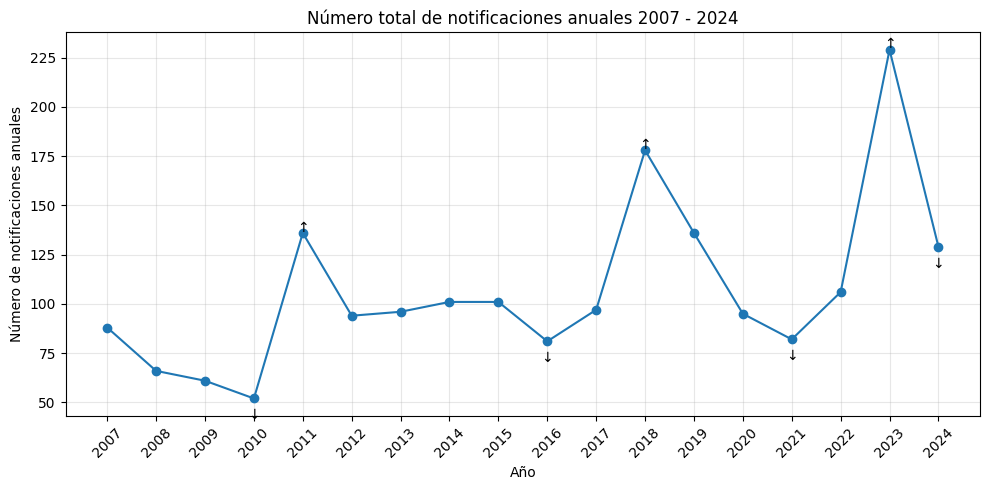

In [5]:
#A.1.1 Overall trend
import matplotlib.pyplot as plt

# Conteo por año con df de las comunas
eno_year = (eno_com["anho_notificacion"].value_counts().sort_index())

# Años que se observan cambios (basado en el gráfico)
increase_years = [2011, 2018, 2023]
decrease_years = [2010, 2016, 2021, 2024]
#Gráfico
plt.figure(figsize=(10, 5))
plt.plot(eno_year.index, eno_year.values, marker="o")

# Marcar aumentos
for year in increase_years:
    plt.annotate("↑",(year, eno_year[year]),textcoords="offset points",xytext=(0,1),ha='center')

# Marcar disminuciones
for year in decrease_years:
    plt.annotate("↓",(year, eno_year[year]),textcoords="offset points",xytext=(0,-15),ha='center')

plt.title("Número total de notificaciones anuales 2007 - 2024")
plt.xlabel("Año")
plt.ylabel("Número de notificaciones anuales")
plt.xticks(eno_year.index, rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Se observan aumentos relevantes en años como 2011, 2018 y 2023, mientras que se registran caídas importantes en el año 2010 y en períodos como 2020–2021. Estos cambios podrían reflejar variaciones en la vigilancia epidemiológica o eventos sanitarios específicos, como la pandemia de COVID-19.

nacionalidad,Chile,Extranjero
anho_notificacion,,
2007,21,0
2008,8,0
2009,31,0
2010,21,0
2011,55,0
2012,3,0
2013,4,1
2014,13,4
2015,52,2


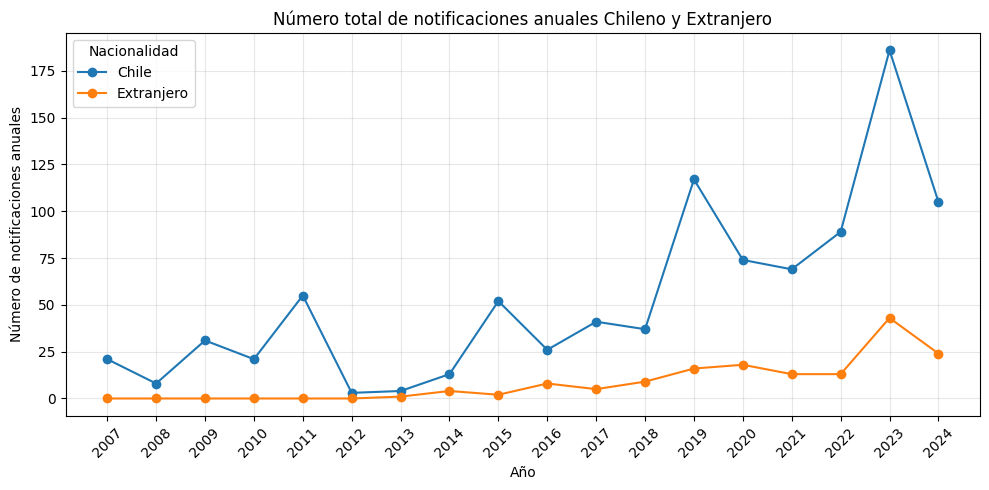

In [6]:
#A.1.2 Trend by nationality (excluyendo "Desconocido")

# Agrupar por año y nacionalidad
eno_year_nat = (eno_com_nat.groupby(["anho_notificacion", "nacionalidad"]).size().unstack(fill_value=0).sort_index())
display(eno_year_nat)

# Gráfico de líneas
plt.figure(figsize=(10, 5))
for col in eno_year_nat.columns:
    plt.plot(eno_year_nat.index,eno_year_nat[col],marker="o",label=col)
plt.title("Número total de notificaciones anuales Chileno y Extranjero")
plt.xlabel("Año")
plt.ylabel("Número de notificaciones anuales")
plt.xticks(eno_year_nat.index, rotation=45)
plt.legend(title="Nacionalidad")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Se observa que los casos correspondientes a población chilena dominan ampliamente en todos los años del período.

Sin embargo, la participación de personas extranjeras muestra un cambio relevante en el tiempo. En los primeros años (2007–2012), las notificaciones de extranjeros son prácticamente nulas, mientras que a partir de aproximadamente 2014 comienzan a aumentar de manera sostenida.

Este aumento se hace más evidente en los años recientes, especialmente entre 2019 y 2023, donde se observa un crecimiento significativo en el número de notificaciones correspondientes a población extranjera.

,n_notificaciones
ENO,
Infección gonocócica,20
Hepatitis B,22
Fiebre Tifoidea y Paratifoidea,25
Meningitis Bacteriana,31
Enfermedad meningocócica,39
Sifilis,120
Chagas,142
Coqueluche,331
Parotiditis,460


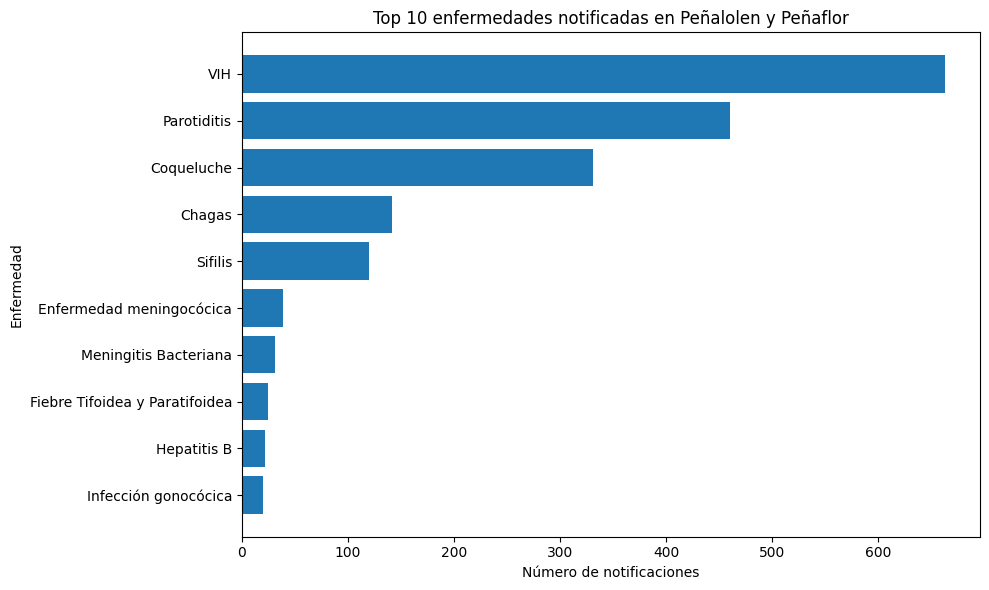

In [7]:
#A.2.1 Top diseases overall (columna ENO)
#Top 10 enfermedades notificadas en las comunas analizadas
top10_eno = (eno_com["ENO"].value_counts().head(10).sort_values(ascending=True)) #cuenta enfermedades y ordenado ascendente
display(top10_eno.to_frame(name="n_notificaciones"))
plt.figure(figsize=(10, 6))
plt.barh(top10_eno.index, top10_eno.values)
plt.title("Top 10 enfermedades notificadas en Peñalolen y Peñaflor")
plt.xlabel("Número de notificaciones")
plt.ylabel("Enfermedad")
plt.tight_layout()
plt.show()

El gráfico muestra las 10 enfermedades de notificación obligatoria más frecuentes en las comunas analizadas. Destaca el VIH como la enfermedad con mayor número de notificaciones, seguido por parotiditis y coqueluche. En conjunto, estas enfermedades concentran una proporción importante de los casos, lo que indica que el perfil epidemiológico local está dominado por un grupo reducido de patologías.

nacionalidad,Chile,Extranjero
ENO,,
Chagas,0.929078,0.070922
Coqueluche,0.928571,0.071429
Parotiditis,0.968354,0.031646
Sifilis,0.841667,0.158333
VIH,0.809259,0.190741


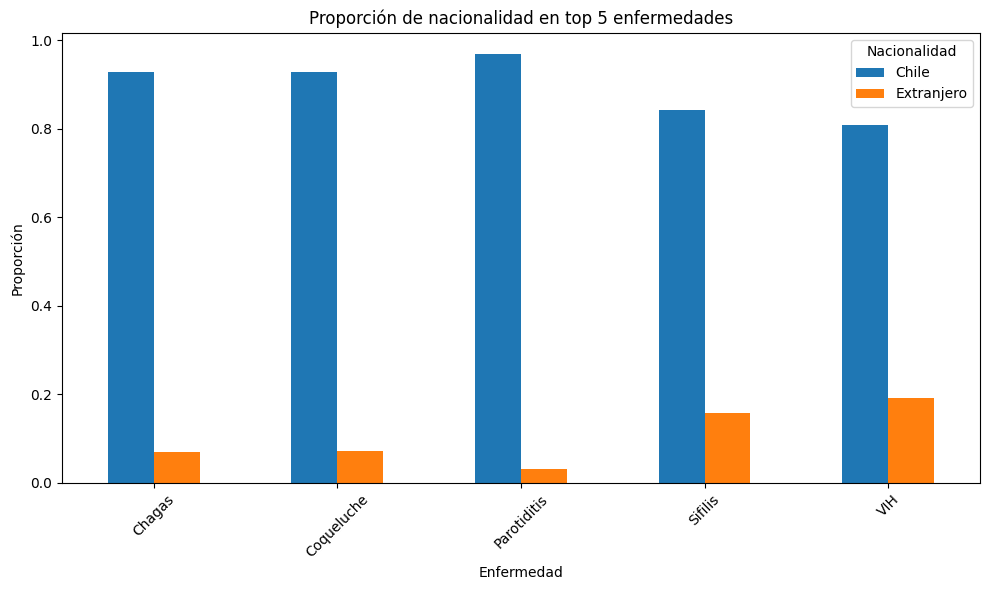

In [8]:
#A.2.2 Disease profiles by nationality

#obtenemos top 5 enfermedades
top5 = eno_com["ENO"].value_counts().head(5).index
eno_top5 = eno_com_nat[eno_com_nat["ENO"].isin(top5)] #subconjuto
#Tabla con datos ordenados
eno_top5_nat = (eno_top5.groupby(["ENO", "nacionalidad"]).size().unstack(fill_value=0))
#proporciones
eno_top5_pct = eno_top5_nat.div(eno_top5_nat.sum(axis=1), axis=0)
display(eno_top5_pct)
eno_top5_pct.plot(kind="bar", figsize=(10,6))
plt.title("Proporción de nacionalidad en top 5 enfermedades")
plt.xlabel("Enfermedad")
plt.ylabel("Proporción")
plt.xticks(rotation=45)
plt.legend(title="Nacionalidad")
plt.tight_layout()
plt.show()

La mayoría de las notificaciones corresponde a población chilena. Sin embargo, la participación de población extranjera no es igual en todas las enfermedades. En particular, VIH y sífilis muestran una proporción relativamente mayor de notificaciones en extranjeros (19% y 16% extranjeros), mientras que parotiditis, coqueluche y Chagas presentan una composición más concentrada en población chilena (96%, 93% y 93% chilenos). Esto sugiere que el perfil por nacionalidad varía según la enfermedad y que algunas patologías podrían estar relativamente sobrerrepresentadas en población extranjera.

Enfermedad más frecuente: VIH
grupo_edad
25-29    103
30-34     89
20-24     86
35-39     73
45-49     53
40-44     49
50-54     28
15-19     18
55-59     16
60-64     11
65-69      4
70-74      2
00-04      2
10-14      2
80y+       1
05-09      1
Name: count, dtype: int64


nacionalidad,Chile,Extranjero
grupo_edad,,
00-04,1,1
05-09,1,0
10-14,2,0
15-19,15,3
20-24,73,13
25-29,79,24
30-34,67,22
35-39,55,18
40-44,42,7


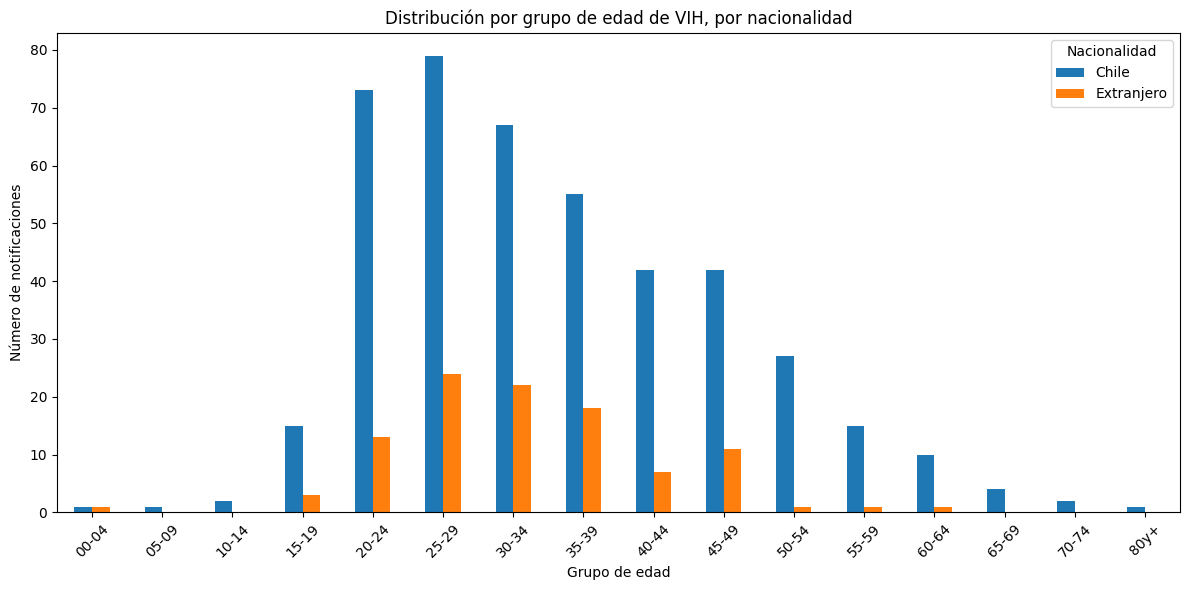

In [9]:
#A.2.3 Age-group distribution for the top disease

# Enfermedad más frecuente en el total de mis comunas
top_disease = eno_com["ENO"].value_counts().idxmax()
print(f"Enfermedad más frecuente: {top_disease}")

# Filtrar esa enfermedad en la base sin "Desconocido"
eno_top_disease = eno_com_nat[eno_com_nat["ENO"] == top_disease].copy()
# Eliminar valores inválidos de grupo_edad
eno_top_disease = eno_top_disease[eno_top_disease["grupo_edad"].notna() &(eno_top_disease["grupo_edad"] != "***")].copy()
print(eno_top_disease["grupo_edad"].value_counts())
# Tabla de conteos por grupo_edad y nacionalidad
age_nat_counts = (eno_top_disease.groupby(["grupo_edad", "nacionalidad"]).size().unstack(fill_value=0))
display(age_nat_counts)

# Gráfico
age_nat_counts.plot(kind="bar", figsize=(12,6))
plt.title(f"Distribución por grupo de edad de {top_disease}, por nacionalidad")
plt.xlabel("Grupo de edad")
plt.ylabel("Número de notificaciones")
plt.xticks(rotation=45)
plt.legend(title="Nacionalidad")
plt.tight_layout()
plt.show()

Para la enfermedad más frecuente (VIH), se observa que la distribución de notificaciones se concentra principalmente en grupos etarios adultos jóvenes, especialmente entre los 20 y 39 años, con un peak en el grupo 25–29 años.

Esta concentración se mantiene tanto en población chilena como extranjera, lo que sugiere un patrón epidemiológico similar entre ambas nacionalidades pero con disntintas propociones.

Sin embargo, se observa que la población extranjera tiene una presencia relativamente importante en estos mismos grupos etarios, particularmente entre 25–34 años, lo que podría indicar una mayor exposición o detección en población en edad laboral.

En los grupos de mayor edad, la cantidad de casos disminuye progresivamente en ambas nacionalidades, y en los grupos infantiles los casos son casi inexistentes.

En conjunto, estos resultados indican que el VIH en las comunas analizadas se concentra principalmente en adultos jóvenes, con un comportamiento simmiliar (en distintas proporciones) en la distribución por edad entre población chilena y extranjera.

float64


,codigo_comuna_residencia,eno_total
0,13122,1487
1,13605,441


0    13122
1    13605
Name: codigo_comuna_residencia, dtype: object


,codigo_comuna_residencia,eno_total,codigo_comuna,nombre_comuna,pop_total,eno_rate_per_10k
0,13122,1487,13122,Peñalolén,236478.0,62.88
1,13605,441,13605,Peñaflor,94402.0,46.72


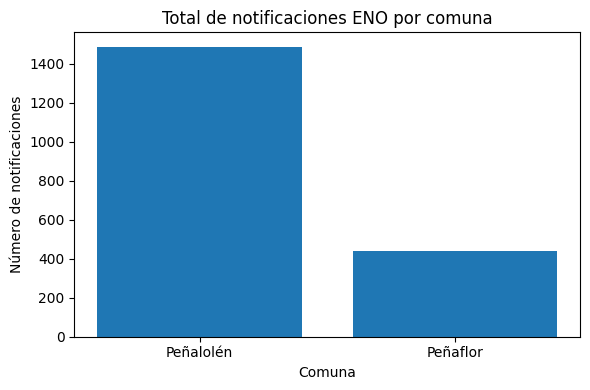

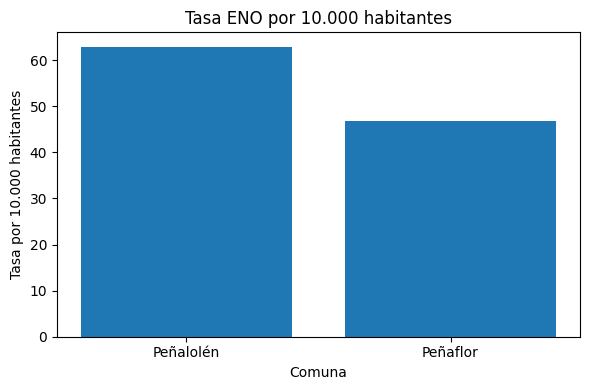

In [10]:
#A.3.1 Notification counts by comuna

# Cargar resumen de Tarea 1
tarea1 = pd.read_csv("tarea1_comuna_summary.csv")
print(tarea1["codigo_comuna"].dtype)
# Normalizar códigos para que coincidan
tarea1["codigo_comuna"] = tarea1["codigo_comuna"].astype(float).astype(int).astype(str)

# Conteo total ENO por comuna
eno_by_comuna = (eno_com.groupby("codigo_comuna_residencia").size().reset_index(name="eno_total"))
display(eno_by_comuna)
eno_by_comuna["codigo_comuna_residencia"] = eno_by_comuna["codigo_comuna_residencia"].astype(str)
print(eno_by_comuna["codigo_comuna_residencia"])

# Asegurar formato consistente y poder calcular cada 10k
tarea1["codigo_comuna"] = tarea1["codigo_comuna"].astype(str)
eno_by_comuna["codigo_comuna_residencia"] = eno_by_comuna["codigo_comuna_residencia"].astype(str)
#Merge antre ambas bases
eno_rates = eno_by_comuna.merge(tarea1[["codigo_comuna", "nombre_comuna", "pop_total"]],left_on="codigo_comuna_residencia",right_on="codigo_comuna",how="left")
#genera nuva columna para cada 10k
eno_rates["eno_rate_per_10k"] = (eno_rates["eno_total"] / eno_rates["pop_total"] * 10000).round(2)
display(eno_rates)

#Gráficos
plt.figure(figsize=(6,4))
plt.bar(eno_rates["nombre_comuna"], eno_rates["eno_total"])
plt.title("Total de notificaciones ENO por comuna")
plt.xlabel("Comuna")
plt.ylabel("Número de notificaciones")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.bar(eno_rates["nombre_comuna"], eno_rates["eno_rate_per_10k"])
plt.title("Tasa ENO por 10.000 habitantes")
plt.xlabel("Comuna")
plt.ylabel("Tasa por 10.000 habitantes")
plt.tight_layout()
plt.show()

El análisis muestra que la comuna de Peñalolén presenta un mayor número total de notificaciones ENO en comparación con Peñaflor.

Al ajustar por población, esta diferencia se mantiene, ya que Peñalolén también presenta una mayor tasa de notificaciones (62.88 por 10.000 habitantes) en comparación con Peñaflor (46.72 por 10.000 habitantes).

La diferencia observada podría estar influenciada por factores como mayor acceso a servicios de salud, diferencias demográficas o mayor capacidad de detección en una comuna respecto a otra.

Las notificaciones están subestimadas debido a la existencia de registros con comuna anonimizada ("*****"), los cuales no pueden ser asignados a una comuna específica.

In [11]:
#A.4 Comuna-Level ENO Summary Table
#Función para construir tabal resumen pedido
def build_eno_summary(df):
    total = len(df)
    eno_chile = (df["nacionalidad"] == "Chile").sum()
    eno_foreign = (df["nacionalidad"] == "Extranjero").sum()
    eno_desconocido = (df["nacionalidad"] == "Desconocido").sum()
    # Top 3 enfermedades
    top3 = df["ENO"].value_counts().head(3).index.tolist()
    top3_str = ", ".join(top3)
    return pd.Series({
        "eno_total": total,
        "eno_chilean": eno_chile,
        "eno_foreign": eno_foreign,
        "eno_desconocido": eno_desconocido,
        "eno_top3_diseases": top3_str})

#construccion por comuna
eno_summary = (eno_com.groupby("codigo_comuna_residencia").apply(build_eno_summary).reset_index())
eno_summary = eno_summary.merge(
    eno_rates[[
        "codigo_comuna_residencia",
        "nombre_comuna",
        "pop_total",
        "eno_rate_per_10k"]],on="codigo_comuna_residencia",how="left")
#variables pedidas
eno_summary = eno_summary[[
    "codigo_comuna_residencia","nombre_comuna","eno_total",
    "eno_chilean","eno_foreign","eno_desconocido","eno_top3_diseases","eno_rate_per_10k"]]
display(eno_summary)
eno_summary.to_csv("tarea2_eno_summary.csv", index=False)

/tmp/ipykernel_143799/1223712402.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eno_summary = (eno_com.groupby("codigo_comuna_residencia").apply(build_eno_summary).reset_index())


,codigo_comuna_residencia,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,13122,Peñalolén,1487,701,124,662,"VIH, Parotiditis, Coqueluche",62.88
1,13605,Peñaflor,441,251,32,158,"VIH, Parotiditis, Coqueluche",46.72


## **Part B: GRD – Hospital Discharges**

In [12]:
# B.0.1 Load GRD files for 2022–2024
import zipfile
import pandas as pd
#variables necesarias
grd_cols = ["COMUNA", "NACIONALIDAD", "SEXO", "FECHA_NACIMIENTO",
    "FECHA_INGRESO", "FECHAALTA", "TIPOALTA","DIAGNOSTICO1", "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD", "TIPO_INGRESO","ESPECIALIDAD_MEDICA"]
#previamente verifique el enconding en cada año para facilitar carga de los zip
encodings = {2022: "utf-16",2023: "utf-16",2024: "latin-1"}
frames = []

for year in [2022, 2023, 2024]:
    zippath = f"/content/GRD_PUBLICO_{year}.zip"
    with zipfile.ZipFile(zippath) as z:
        txtname = [f for f in z.namelist() if f.endswith(".txt")][0]
        with z.open(txtname) as f:
            df_year = pd.read_csv(f,sep="|",usecols=grd_cols,encoding=encodings[year],low_memory=False)
    df_year["year"] = year
    frames.append(df_year)

grd = pd.concat(frames, ignore_index=True)
print(f"Total discharges (3 years): {len(grd):,}")
display(grd["year"].value_counts().sort_index())

Total discharges (3 years): 3,058,240


,count
year,
2022,932840
2023,1039587
2024,1085813


In [13]:
#B.0.2 Filter to your comunas
my_comunas_names = ["PEÑALOLÉN", "PEÑAFLOR"]
grd_com = grd[grd["COMUNA"].isin(my_comunas_names)].copy()
print(f"Discharges in my comunas: {len(grd_com):,}")
#egresos por año
discharges_year = grd_com.groupby("year").size()
print(discharges_year)

Discharges in my comunas: 55,276
year
2022    17497
2023    19170
2024    18609
dtype: int64


El número de egresos hospitalarios en mis comunas varía por año. En 2022 se registraron 17.497 egresos, en 2023 hubo 19.170, y en 2024 se observaron 18.609 egresos. En total, se contabilizan 55.276 egresos en el período 2022–2024.


In [14]:
#B.0.3 Compute length of stay

# Convertir fechas
grd_com["fecha_ingreso_dt"] = pd.to_datetime(grd_com["FECHA_INGRESO"], errors="coerce")
grd_com["fecha_alta_dt"] = pd.to_datetime(grd_com["FECHAALTA"], errors="coerce")

# Calcular los
grd_com["los"] = (grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]).dt.days
# Contar valores negativos (errores)
neg_los = (grd_com["los"] < 0).sum()
# Filtrar datos válidos
grd_com_clean = grd_com[grd_com["los"] >= 0]
# Estadísticas solicitadas
los_stats = grd_com_clean["los"].agg(["mean", "median", "min", "max"])
print("Número de registros con LOS negativo eliminados:", neg_los)
print("\nDistribución de LOS:")
print(los_stats)

Número de registros con LOS negativo eliminados: 0

Distribución de LOS:
mean        5.491179
median      2.000000
min         0.000000
max       621.000000
Name: los, dtype: float64


No se encontraron valores negativos, por lo que no fue necesario eliminar registros. La duración promedio es de aproximadamente 5,49 días, con una mediana de 2 días, lo que sugiere una distribución sesgada a la derecha debido a algunos valores extremos.

In [15]:
#B.0.4 Create a nationality grouping
# Crear variable binaria de nacionalidad
grd_com["nat_group"] = grd_com["NACIONALIDAD"].apply(lambda x: "Chilean" if x == "CHILE" else "Foreign")

#distribución para responder
# Conteo
nat_distribution = grd_com["nat_group"].value_counts()
# Porcentajes
nat_percentage = grd_com["nat_group"].value_counts(normalize=True) * 100
# Combinar en una tabla
nat_summary = pd.DataFrame({"count": nat_distribution,"percentage (%)": nat_percentage.round(2)})
print(nat_summary)

           count  percentage (%)
nat_group                       
Chilean    52030           94.13
Foreign     3246            5.87


La gran mayoría de las hospitalizaciones en las comunas corresponden a pacientes chilenos (52,030 casos, 94,13%), mientras que una proporción mucho menor corresponde a pacientes extranjeros (3,246 casos, 5.87%). Esto indica que la demanda hospitalaria está dominada principalmente por población nacional.

In [16]:
#B.0.5 Join diagnoses to CIE-10
#cargamos nuevo archivo y hacemos merge con el df anterior
cie10 = pd.read_excel("/content/CIE-10.xlsx",sheet_name="CIE 10")
grd_com = grd_com.merge(cie10[["Código", "Descripción", "Capítulo"]].drop_duplicates("Código"),left_on="DIAGNOSTICO1", right_on="Código", how="left")

In [17]:
# Conteo absoluto
n_no_match = grd_com["Capítulo"].isna().sum()
# Porcentaje
pct_no_match = n_no_match / len(grd_com) * 100
print(n_no_match)
print(pct_no_match)

2
0.0036182068167016426


Después del cruce con la tabla CIE-10, 2 registros no encontraron match, es decir, su columna Capítulo quedó nula. Esto representa una proporción despreciable del total.

## **B.1 Diagnostic Profile**

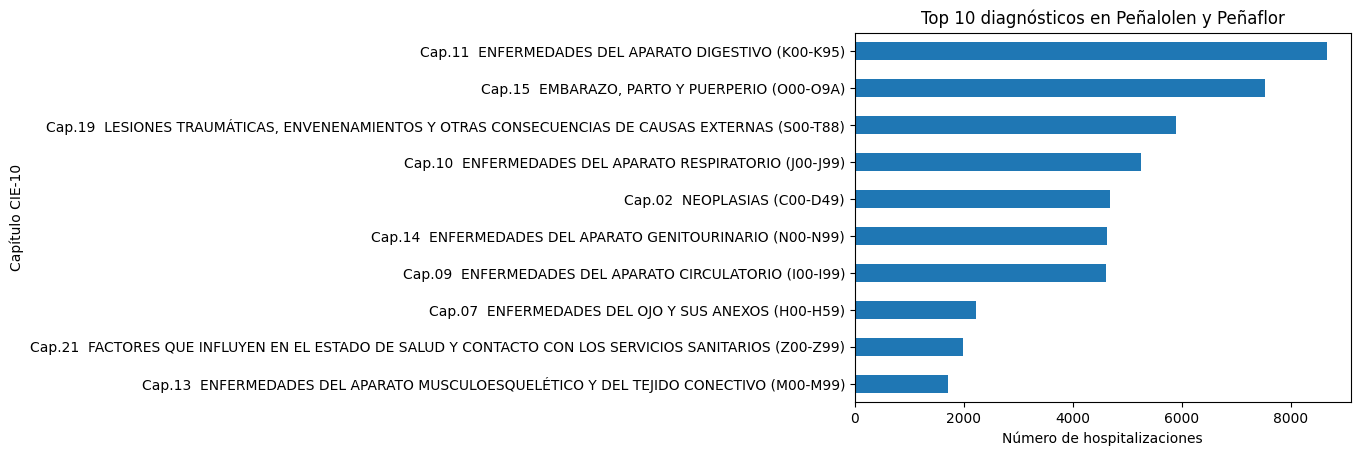

In [18]:
#B.1.1 Top diagnostic chapters
grd_com = grd_com.dropna(subset=["Capítulo"])
# Agrupar por capítulo y contar
top_capitulos = (grd_com["Capítulo"].value_counts().head(10)
    .sort_values(ascending=True))  # para gráfico horizontal ordenado

# Gráfico de barras horizontal
plt.figure()
top_capitulos.plot(kind="barh")
plt.xlabel("Número de hospitalizaciones")
plt.ylabel("Capítulo CIE-10")
plt.title("Top 10 diagnósticos en Peñalolen y Peñaflor")
plt.show()

Las hospitalizaciones están dominadas principalmente por enfermedades del sistema digestivo, seguidas por condiciones relacionadas con embarazo, parto y puerperio, y lesiones o causas externas. También destacan las enfermedades respiratorias. En conjunto, esto sugiere que la demanda hospitalaria se explica por una combinación de enfermedades crónicas y asociada a salud materna.

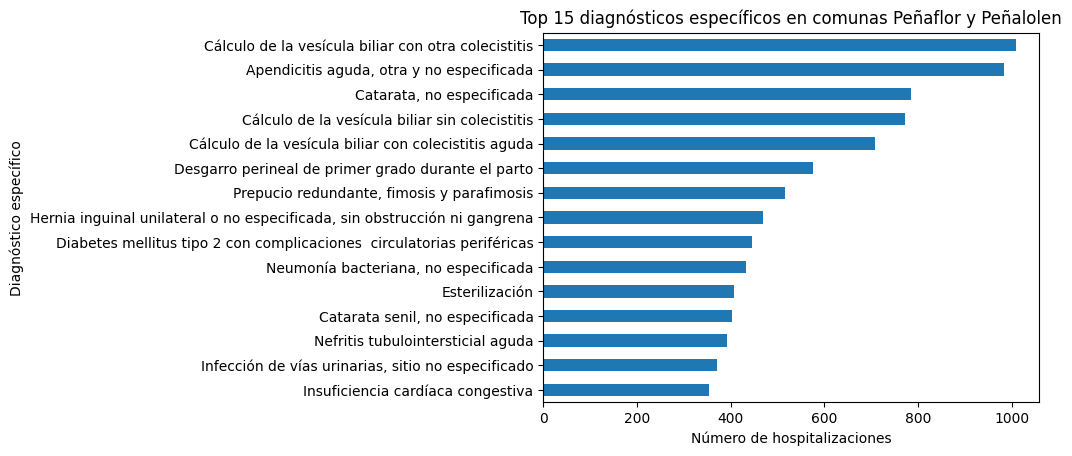

In [19]:
#B.1.2 Top specific diagnoses

# Agrupar por descripción y contar
top_diagnosticos = (grd_com["Descripción"].value_counts().head(15) #top 15
    .sort_values(ascending=True))  # para gráfico horizontal ordenado
# Gráfico horizontal
plt.figure()
top_diagnosticos.plot(kind="barh")
plt.xlabel("Número de hospitalizaciones")
plt.ylabel("Diagnóstico específico")
plt.title("Top 15 diagnósticos específicos en comunas Peñaflor y Peñalolen")
plt.show()

nat_group,Chilean,Foreign
Capítulo,,
Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95),8182,481
"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",6199,1332
"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88)",5597,289
Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO (J00-J99),5128,127
Cap.02 NEOPLASIAS (C00-D49),4391,287


nat_group,Chilean,Foreign
Capítulo,,
Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95),0.944477,0.055523
"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",0.823131,0.176869
"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88)",0.950900,0.049100
Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO (J00-J99),0.975833,0.024167
Cap.02 NEOPLASIAS (C00-D49),0.938649,0.061351


/tmp/ipykernel_143799/260458491.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


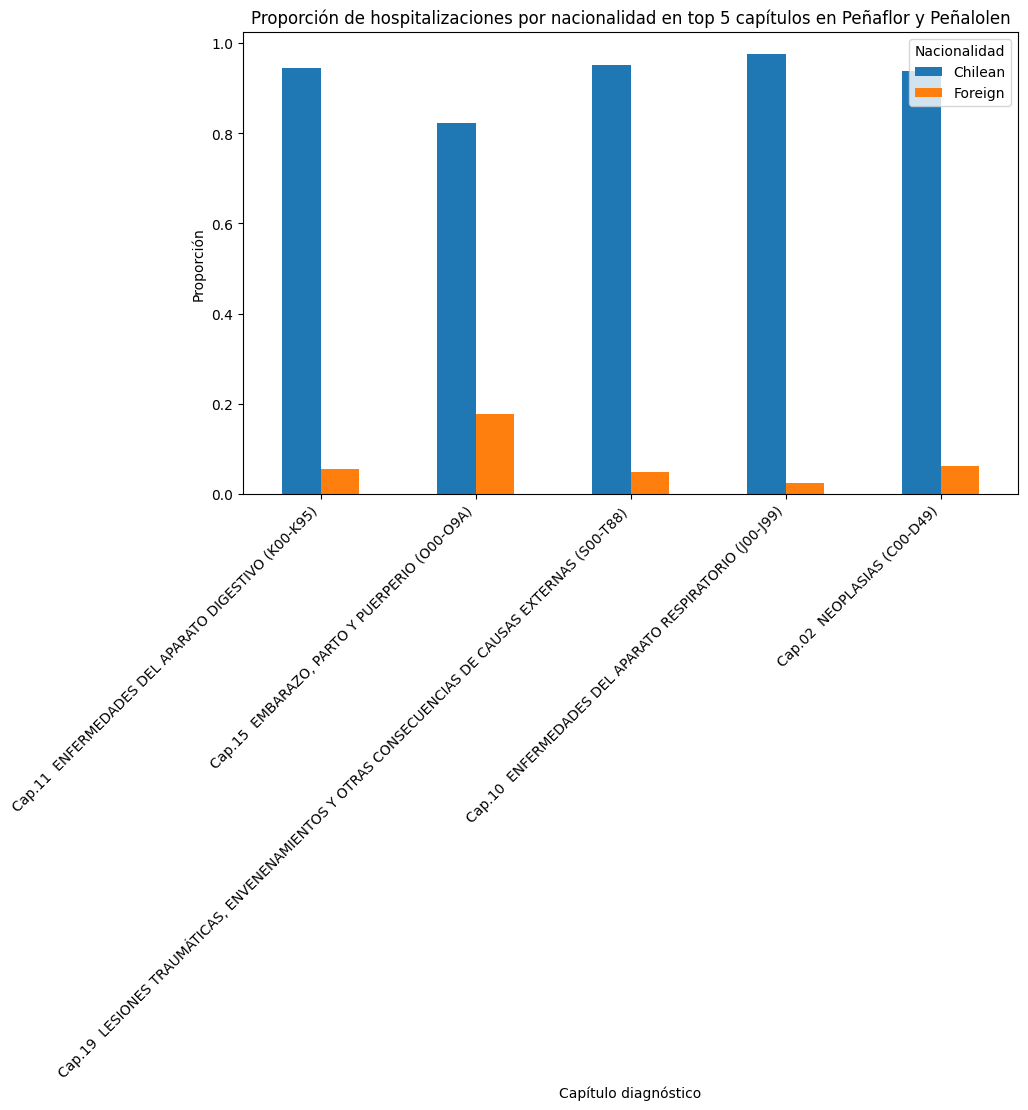

In [20]:
#B.1.3 Diagnostic chapters by nationality

# Top 5 capítulos diagnósticos
top5_capitulos = grd_com["Capítulo"].value_counts().head(5).index
# Filtrar solo esos capítulos
grd_top5 = grd_com[grd_com["Capítulo"].isin(top5_capitulos)].copy()
# Tabla de conteos por capítulo y nacionalidad
chap_nat_counts = (grd_top5.groupby(["Capítulo", "nat_group"]).size().unstack(fill_value=0).reindex(top5_capitulos))
#imprime datos apra verificar
display(chap_nat_counts)

# Convertir a proporciones dentro de cada capítulo
chap_nat_pct = chap_nat_counts.div(chap_nat_counts.sum(axis=1), axis=0)
display(chap_nat_pct)

# Gráfico bar chart
chap_nat_pct.plot(kind="bar", figsize=(10, 6))
plt.title("Proporción de hospitalizaciones por nacionalidad en top 5 capítulos en Peñaflor y Peñalolen")
plt.xlabel("Capítulo diagnóstico")
plt.ylabel("Proporción")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Nacionalidad")
plt.tight_layout()
plt.show()

En general, los pacientes extranjeros representan aproximadamente el 5.9% de las hospitalizaciones. Sin embargo, en el Capítulo 15 (embarazo, parto y puerperio), la proporción de pacientes extranjeros alcanza cerca del 17.7%. En los demás capítulos, la participación de extranjeros es inferior al promedio general (ej. ENFERMEDADES DEL APARATO DIGESTIVO  5,5%), por lo que no se observa una sobre-representación relevante.

## **B.2 Length of Stay & Severity**

,mean,median
nat_group,,
Chilean,5.57,2.0
Foreign,4.28,2.0


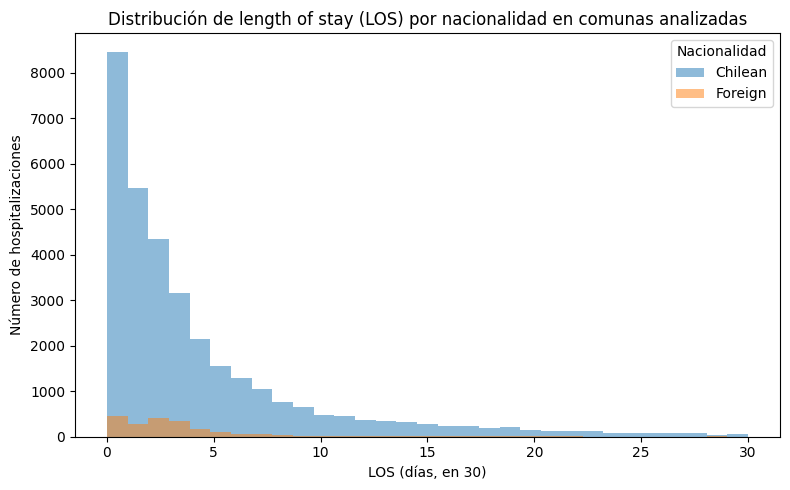

In [21]:
# B.2.1 Length of stay by nationality

# Tabla con media y mediana de LOS por nacionalidad
los_summary = (grd_com.groupby("nat_group")["los"].agg(["mean", "median"]).round(2))
display(los_summary)

# Datos capados en 30 días para visualización
grd_los_30 = grd_com[grd_com["los"] <= 30].copy()

# Histograma
plt.figure(figsize=(8, 5))
for group in ["Chilean", "Foreign"]:
    subset = grd_los_30[grd_los_30["nat_group"] == group]["los"]
    plt.hist(subset, bins=31, alpha=0.5, label=group)
plt.title("Distribución de length of stay (LOS) por nacionalidad en comunas analizadas")
plt.xlabel("LOS (días, en 30)")
plt.ylabel("Número de hospitalizaciones")
plt.legend(title="Nacionalidad")
plt.tight_layout()
plt.show()

La mediana del tiempo de hospitalización es igual para ambos grupos (2 días), lo que indica que el comportamiento típico es muy similar entre pacientes chilenos y extranjeros. Sin embargo, la media es mayor en pacientes chilenos (5.57 vs. 4.28 días), lo que sugiere la presencia de estancias más largas en este grupo.

En general, las distribuciones son bastante similares, con una alta concentración de hospitalizaciones cortas y algunas estancias prolongadas (outliers). Por lo tanto, no se observan diferencias sustanciales en la duración de hospitalización entre ambos grupos, aunque los pacientes chilenos presentan una mayor variabilidad.

,Codigo,Descripcion
0,0,Sin gravedad
1,1,Menor
2,2,Moderada
3,3,Mayor


,IR_29301_SEVERIDAD,IR_29301_SEVERIDAD_num,severity_label
0,3,3,Mayor
1,2,2,Moderada
2,0,0,Sin gravedad
3,2,2,Moderada
4,1,1,Menor
5,2,2,Moderada
6,1,1,Menor
7,2,2,Moderada
8,2,2,Moderada
9,1,1,Menor


nat_group,Chilean,Foreign
severity_label,,
Mayor,0.229857,0.143561
Menor,0.291651,0.390943
Moderada,0.274179,0.308380
Sin gravedad,0.204313,0.157116


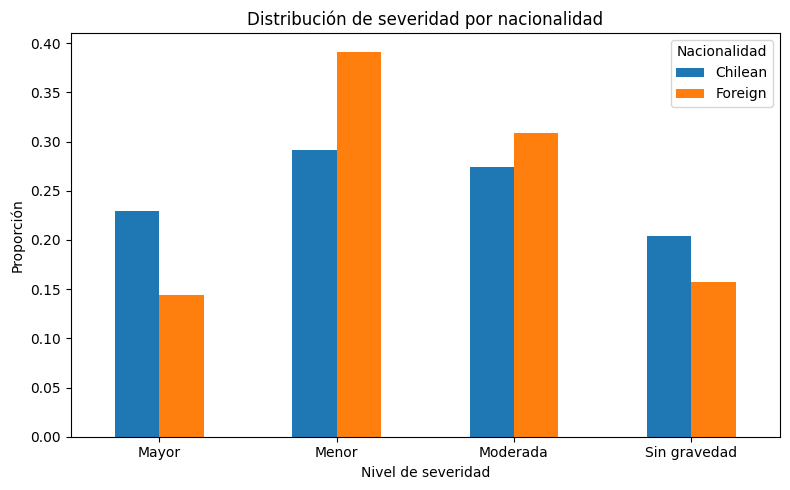

In [22]:
# B.2.2 Severity distribution

# Cargar tabla maestra de severidad
sev_table = pd.read_excel("/content/TablasMaestrasBasesGRD.xlsx",sheet_name="Severidad GRD")

#Dejar solo las dos primeras columnas y renombrarlas
sev_table = sev_table.iloc[:, :2].copy()
sev_table.columns = ["Codigo", "Descripcion"]
#Limpiar filas vacías
sev_table = sev_table.dropna(subset=["Codigo", "Descripcion"]).copy()

# Normalizar tipos para que coincidan con IR_29301_SEVERIDAD
sev_table["Codigo"] = pd.to_numeric(sev_table["Codigo"], errors="coerce")
sev_table = sev_table.dropna(subset=["Codigo"]).copy()
sev_table["Codigo"] = sev_table["Codigo"].astype(int)

grd_com["IR_29301_SEVERIDAD_num"] = pd.to_numeric(grd_com["IR_29301_SEVERIDAD"], errors="coerce")

#Crear diccionario de etiquetas y mapear
sev_map = dict(zip(sev_table["Codigo"], sev_table["Descripcion"]))
grd_com["severity_label"] = grd_com["IR_29301_SEVERIDAD_num"].map(sev_map)

# Verificación
display(sev_table)
display(grd_com[["IR_29301_SEVERIDAD", "IR_29301_SEVERIDAD_num", "severity_label"]].head(10))

# Tabla de distribución por nacionalidad (proporciones)
sev_dist = pd.crosstab(grd_com["severity_label"],grd_com["nat_group"],normalize="columns")
display(sev_dist)

# Gráfico de barras
sev_dist.plot(kind="bar", figsize=(8, 5))
plt.title("Distribución de severidad por nacionalidad")
plt.xlabel("Nivel de severidad")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.legend(title="Nacionalidad")
plt.tight_layout()
plt.show()

La distribución de severidad muestra diferencias claras entre chilenos y extranjeros.
Los pacientes extranjeros presentan una mayor proporción de casos de severidad menor (39.1% vs 29.2%) y moderada (30.8% vs 27.4%), mientras que los chilenos concentran más casos de alta severidad (22.9% vs 14.4%) y sin gravedad (20.4% vs 15.7%).

Esto sugiere que los pacientes extranjeros tienden a hospitalizarse por condiciones menos graves en comparación con los pacientes chilenos.

In [23]:
#B.2.3 Discharge type
# Distribución general de tipo de alta
alta_dist = grd_com["TIPOALTA"].value_counts(normalize=True) * 100
alta_dist = alta_dist.round(2)
print("Distribución de tipo de alta (%):")
print(alta_dist)

#nacionalidad
alta_nat = pd.crosstab(grd_com["TIPOALTA"],grd_com["nat_group"],normalize="columns") * 100
alta_nat = alta_nat.round(2)
display(alta_nat)

#tasa de mortalidad
# Crear variable de muerte (1 si fallecido, 0 si no)
grd_com["is_dead"] = (grd_com["TIPOALTA"] == "FALLECIDO").astype(int)
# Calcular tasa por nacionalidad
mortality_rate = grd_com.groupby("nat_group")["is_dead"].mean() * 100
mortality_table = mortality_rate.round(2).to_frame(name="mortality_rate (%)")
display(mortality_table)


Distribución de tipo de alta (%):
TIPOALTA
DOMICILIO                                        89.20
DERIVACIÓN OTRO HOSPITAL DEL SERVICIO             3.79
FALLECIDO                                         2.72
HOSPITALIZACIÓN DOMICILIARIA                      1.77
ALTA VOLUNTARIA                                   1.43
DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL       0.40
DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE      0.25
DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS     0.19
FUGA DEL PACIENTE                                 0.16
DERIVACIÓN INST. PRIVADA (VOLUNTARIO)             0.09
Name: proportion, dtype: float64


nat_group,Chilean,Foreign
TIPOALTA,,
ALTA VOLUNTARIA,1.45,1.08
"DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE",0.25,0.18
DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS,0.20,0.12
DERIVACIÓN INST. PRIVADA (VOLUNTARIO),0.09,0.06
DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL,0.41,0.18
DERIVACIÓN OTRO HOSPITAL DEL SERVICIO,3.93,1.57
DOMICILIO,88.82,95.19
FALLECIDO,2.84,0.68
FUGA DEL PACIENTE,0.17,0.06


,mortality_rate (%)
nat_group,
Chilean,2.84
Foreign,0.68


La gran mayoría de las hospitalizaciones terminan con alta a domicilio (89.2%), mientras que los fallecimientos representan una proporción baja del total (2.72%).

Al analizar por nacionalidad, se observa que los pacientes extranjeros tienen una mayor proporción de altas a domicilio (95.19% vs 88.82%), mientras que los pacientes chilenos presentan una mayor proporción de fallecimientos (2.84% vs 0.68%) y derivaciones.

La tasa de mortalidad intrahospitalaria es significativamente mayor en pacientes chilenos (2.84%) en comparación con pacientes extranjeros (0.68%).

## **B.3 Spatial View**

Tasas GRD por comuna:


,codigo_comuna,nombre_comuna,pop_total,grd_total,grd_rate_per_10k
0,13122,Peñalolén,236478.0,44917,1899.42
1,13605,Peñaflor,94402.0,10357,1097.12


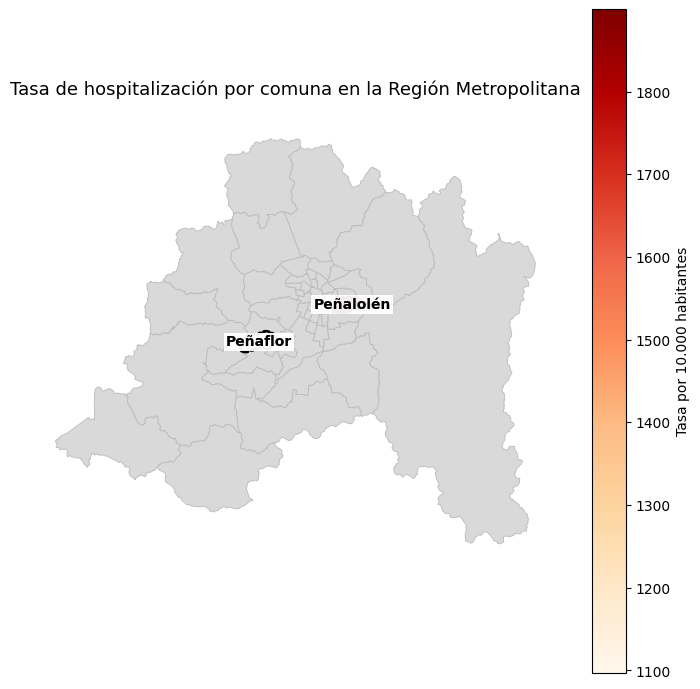

In [24]:
# B.3.1 Choropleth: hospitalization rate by comuna

import pandas as pd
import geopandas as gpd

#cargar tarea 1 y estandarizar variables
tarea1 = pd.read_csv("tarea1_comuna_summary.csv").copy()
tarea1["codigo_comuna"] = pd.to_numeric(tarea1["codigo_comuna"], errors="coerce")
tarea1["pop_total"] = pd.to_numeric(tarea1["pop_total"], errors="coerce")
tarea1 = tarea1.dropna(subset=["codigo_comuna", "pop_total"]).copy()
tarea1["codigo_comuna"] = tarea1["codigo_comuna"].astype(int)

# Normalizar nombres para mapear GRD -> codigo_comuna
tarea1["nombre_comuna_norm"] = (tarea1["nombre_comuna"].astype(str).str.strip().str.upper())
grd_com = grd_com.copy()
grd_com["COMUNA_norm"] = (grd_com["COMUNA"].astype(str).str.strip().str.upper())
# Agregar codigo_comuna al GRD filtrado
grd_com_map = grd_com.merge(tarea1[["codigo_comuna", "nombre_comuna", "nombre_comuna_norm", "pop_total"]],left_on="COMUNA_norm",right_on="nombre_comuna_norm",how="left")
grd_by_comuna = (grd_com_map.dropna(subset=["codigo_comuna"])
    .groupby(["codigo_comuna", "nombre_comuna", "pop_total"], as_index=False).size().rename(columns={"size": "grd_total"}))

grd_by_comuna["codigo_comuna"] = grd_by_comuna["codigo_comuna"].astype(int)
grd_by_comuna["grd_rate_per_10k"] = (grd_by_comuna["grd_total"] / grd_by_comuna["pop_total"] * 10000).round(2)
print("Tasas GRD por comuna:")
display(grd_by_comuna)

#cargar shapeline y determinar RM para mapear la region
comunas_gdf = gpd.read_file("/content/comunas.shp").copy()

comunas_gdf["cod_comuna"] = pd.to_numeric(comunas_gdf["cod_comuna"], errors="coerce")
comunas_gdf["codregion"] = pd.to_numeric(comunas_gdf["codregion"], errors="coerce")

comunas_gdf = comunas_gdf.dropna(subset=["cod_comuna", "codregion"]).copy()
comunas_gdf["cod_comuna"] = comunas_gdf["cod_comuna"].astype(int)
comunas_gdf["codregion"] = comunas_gdf["codregion"].astype(int)

# Región Metropolitana = código 13
rm_gdf = comunas_gdf[comunas_gdf["codregion"] == 13].copy()

# Unir tasas a las comunas de la RM
rm_map = rm_gdf.merge(
    grd_by_comuna[["codigo_comuna", "nombre_comuna", "grd_total", "grd_rate_per_10k"]],
    left_on="cod_comuna",right_on="codigo_comuna",how="left")

# Solo mis comunas analizadas (las que tienen tasa)
mis_comunas_map = rm_map[rm_map["grd_rate_per_10k"].notna()].copy()

# Graficar RM completa +  comunas analizadas
fig, ax = plt.subplots(figsize=(7, 7))
rm_map.plot(
    color="#d9d9d9",#color y fondo gris
    edgecolor="#bbbbbb",
    linewidth=0.6,ax=ax)
# mis comunas coloreadas por tasa
mis_comunas_map.plot(
    column="grd_rate_per_10k",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=1.8,ax=ax,
    legend_kwds={"label": "Tasa por 10.000 habitantes"})

# Etiquetas solo para mis comunas, usando nombre_comuna de Tarea 1
for _, row in mis_comunas_map.iterrows():
    pt = row.geometry.representative_point()
    for _, row in mis_comunas_map.iterrows():
      pt = row.geometry.representative_point()
      ax.text(
          pt.x,
          pt.y,
          row["nombre_comuna"],
          fontsize=10,
          fontweight="bold",
          ha="center",
          va="center",
          bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5))

ax.set_title("Tasa de hospitalización por comuna en la Región Metropolitana", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

Se calculó la tasa de hospitalización por comuna como el total de egresos hospitalarios dividido por la población y multiplicado por 10.000.
Los resultados muestran que Peñalolén presenta una tasa más alta (1899.42) en comparación con Peñaflor (1097.12), lo que indica una mayor carga relativa de hospitalizaciones en Peñalolén.

## **B.4 Comuna-Level GRD Summary Table**

In [25]:
# B.4 Comuna-Level GRD Summary Table
# Reutiliza variables ya creadas antes:grd_com, tarea1, nat_group, los, is_dead, Capítulo

# Agregar codigo_comuna y nombre_comuna correctos desde Tarea 1
tarea1["nombre_comuna_upper"] = tarea1["nombre_comuna"].str.upper()
grd_com["COMUNA_upper"] = grd_com["COMUNA"].str.upper()

grd_b4 = grd_com.merge(tarea1[["codigo_comuna", "nombre_comuna", "nombre_comuna_upper", "pop_total"]],
    left_on="COMUNA_upper",right_on="nombre_comuna_upper",how="left").copy()
grd_b4["codigo_comuna"] = grd_b4["codigo_comuna"].astype(int)

#Función resumen por comuna
def build_grd_summary(df):
    top3 = df["Capítulo"].dropna().value_counts().head(3).index.tolist()
    return pd.Series({
        "grd_total": len(df),
        "grd_chilean": (df["nat_group"] == "Chilean").sum(),
        "grd_foreign": (df["nat_group"] == "Foreign").sum(),
        "grd_pct_foreign": round((df["nat_group"] == "Foreign").mean() * 100, 2),
        "grd_mean_los": round(df["los"].mean(), 2),
        "grd_mean_los_chilean": round(df.loc[df["nat_group"] == "Chilean", "los"].mean(), 2),
        "grd_mean_los_foreign": round(df.loc[df["nat_group"] == "Foreign", "los"].mean(), 2),
        "grd_mean_severity": round(pd.to_numeric(df["IR_29301_SEVERIDAD"], errors="coerce").mean(), 2),
        "grd_mortality_rate": round(df["is_dead"].mean() * 100, 2),
        "grd_top3_chapters": ", ".join(top3)})

# Construir tabla final
grd_summary = (grd_b4.groupby(["codigo_comuna", "nombre_comuna", "pop_total"]).apply(build_grd_summary).reset_index())
#  Calcular tasa por 10.000
grd_summary["grd_rate_per_10k"] = ( grd_summary["grd_total"] / grd_summary["pop_total"] * 10000).round(2)

# Dejar solo columnas pedidas
grd_summary = grd_summary[[
    "codigo_comuna",
    "nombre_comuna",
    "grd_total",
    "grd_chilean",
    "grd_foreign",
    "grd_pct_foreign",
    "grd_mean_los",
    "grd_mean_los_chilean",
    "grd_mean_los_foreign",
    "grd_mean_severity",
    "grd_mortality_rate",
    "grd_top3_chapters",
    "grd_rate_per_10k"]].sort_values("codigo_comuna")
display(grd_summary)

#Guardar a CSV
grd_summary.to_csv("tarea2_grd_summary.csv", index=False)
print("Archivo guardado: tarea2_grd_summary.csv")

/tmp/ipykernel_143799/393194068.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grd_summary = (grd_b4.groupby(["codigo_comuna", "nombre_comuna", "pop_total"]).apply(build_grd_summary).reset_index())


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13122,Peñalolén,44917,42047,2870,6.39,5.34,5.43,4.14,1.56,2.91,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,1899.42
1,13605,Peñaflor,10357,9981,376,3.63,6.14,6.17,5.43,1.39,1.89,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,1097.12


Archivo guardado: tarea2_grd_summary.csv
